In [212]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import euclidean_distances

### the aim of this project is to find a new MO SALAH. the player should be a comming star not and not very well known or plays in a top level club
### Looking at Salah's features. salah is/has
* Winger
* Fast
* Vision
* High strength
* High shooting accuracy
* High acceleration, stamina, and agility
* Good with penalties

In [142]:
df = pd.read_csv('player_stats.csv', encoding= "latin-1")
df.head()

,player,country,height,weight,age,club,ball_control,dribbling,marking,slide_tackle,...,curve,fk_acc,penalties,volleys,gk_positioning,gk_diving,gk_handling,gk_kicking,gk_reflexes,value
0,Cristian Castro Devenish,Colombia,192,84,22,Atl. Nacional,55,43,NaN,68,...,32,34,41,33,10,11,6,7,9,$1.400.000
1,Silaldo Taffarel,Brazil,181,80,31,Corinthians,69,70,NaN,56,...,65,62,48,46,12,15,14,8,14,$975.00
2,Thomas DÃ¤hne,Germany,193,84,29,Holstein Kiel,25,12,NaN,13,...,20,15,26,16,64,74,65,68,74,$1.100.000
3,Michael Sollbauer,Austria,187,86,33,SK Rapid Wien,46,48,NaN,66,...,25,13,22,19,10,10,8,14,9,$650.00
4,Diego Segovia,Uruguay,191,80,23,Independiente,14,8,NaN,14,...,9,10,16,5,61,59,62,64,64,$300.00


### A few observations from the dataset
* The dataset has 5682 players with 41 characteristics
* It covers players who are over 40 years old
* It doesn't have a position columns which specifies exactly the player's position
* The dataset covers the Goal Keepers as well
* The max value of the player's attributes is 100

In [143]:
df.shape

(5682, 41)

In [144]:
df.columns

Index(['player', 'country', 'height', 'weight', 'age', 'club', 'ball_control',
       'dribbling', 'marking', 'slide_tackle', 'stand_tackle', 'aggression',
       'reactions', 'att_position', 'interceptions', 'vision', 'composure',
       'crossing', 'short_pass', 'long_pass', 'acceleration', 'stamina',
       'strength', 'balance', 'sprint_speed', 'agility', 'jumping', 'heading',
       'shot_power', 'finishing', 'long_shots', 'curve', 'fk_acc', 'penalties',
       'volleys', 'gk_positioning', 'gk_diving', 'gk_handling', 'gk_kicking',
       'gk_reflexes', 'value'],
      dtype='object')

In [145]:
df.describe()

,height,weight,age,ball_control,dribbling,marking,slide_tackle,stand_tackle,aggression,reactions,...,long_shots,curve,fk_acc,penalties,volleys,gk_positioning,gk_diving,gk_handling,gk_kicking,gk_reflexes
count,5682.000000,5682.000000,5682.000000,5682.000000,5682.000000,0.0,5682.000000,5682.000000,5682.000000,5682.000000,...,5682.000000,5682.000000,5682.000000,5682.000000,5682.000000,5682.000000,5682.00000,5682.000000,5682.000000,5682.000000
mean,181.670539,75.282295,26.316262,58.912179,56.128476,NaN,46.728441,48.820838,56.324006,61.959345,...,47.164203,48.099789,43.299542,48.174938,42.931890,16.187610,16.43805,16.191834,16.071982,16.570222
std,6.829238,6.998971,4.729967,16.567068,18.772075,NaN,20.519430,20.975966,16.846410,8.893309,...,19.463368,18.086672,17.086473,15.781737,17.912619,17.146572,17.63526,16.993154,16.808674,17.942154
min,156.000000,54.000000,17.000000,8.000000,5.000000,NaN,7.000000,7.000000,11.000000,32.000000,...,5.000000,7.000000,4.000000,8.000000,4.000000,2.000000,2.00000,2.000000,2.000000,3.000000
25%,177.000000,70.000000,23.000000,55.000000,51.000000,NaN,27.000000,30.000000,45.000000,56.000000,...,33.000000,36.000000,32.000000,39.000000,30.000000,8.000000,8.00000,8.000000,8.000000,8.000000
50%,182.000000,75.000000,26.000000,63.000000,62.000000,NaN,54.000000,57.000000,60.000000,62.000000,...,51.000000,50.000000,43.000000,49.000000,44.000000,11.000000,11.00000,11.000000,11.000000,11.000000
75%,186.000000,80.000000,30.000000,69.000000,68.000000,NaN,64.000000,66.000000,69.000000,68.000000,...,62.000000,62.000000,56.000000,60.000000,57.000000,14.000000,14.00000,14.000000,14.000000,14.000000
max,204.000000,102.000000,41.000000,94.000000,95.000000,NaN,87.000000,91.000000,96.000000,93.000000,...,91.000000,93.000000,94.000000,92.000000,90.000000,90.000000,90.00000,87.000000,90.000000,89.000000


In [146]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5682 entries, 0 to 5681
Data columns (total 41 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   player          5682 non-null   object 
 1   country         5682 non-null   object 
 2   height          5682 non-null   int64  
 3   weight          5682 non-null   int64  
 4   age             5682 non-null   int64  
 5   club            5682 non-null   object 
 6   ball_control    5682 non-null   int64  
 7   dribbling       5682 non-null   int64  
 8   marking         0 non-null      float64
 9   slide_tackle    5682 non-null   int64  
 10  stand_tackle    5682 non-null   int64  
 11  aggression      5682 non-null   int64  
 12  reactions       5682 non-null   int64  
 13  att_position    5682 non-null   int64  
 14  interceptions   5682 non-null   int64  
 15  vision          5682 non-null   int64  
 16  composure       5682 non-null   int64  
 17  crossing        5682 non-null   i

### By applying Exploratory Data Analysis, we found that 
* The value column is of object data type
* The marking column is all empty
* fk_acc column is referring to Free Kick Accuracy
* No misspellings or mistakes in column names
* Looking at the duplicated values, there are 3 
#### Thus, changes can be made
* Remove the null column
* Change the value column into int64
* Dropped the repeated players due to a name conversion from different languages

In [147]:
df.dtypes

player             object
country            object
height              int64
weight              int64
age                 int64
club               object
ball_control        int64
dribbling           int64
marking           float64
slide_tackle        int64
stand_tackle        int64
aggression          int64
reactions           int64
att_position        int64
interceptions       int64
vision              int64
composure           int64
crossing            int64
short_pass          int64
long_pass           int64
acceleration        int64
stamina             int64
strength            int64
balance             int64
sprint_speed        int64
agility             int64
jumping             int64
heading             int64
shot_power          int64
finishing           int64
long_shots          int64
curve               int64
fk_acc              int64
penalties           int64
volleys             int64
gk_positioning      int64
gk_diving           int64
gk_handling         int64
gk_kicking  

In [148]:
df.isnull().sum()

player               0
country              0
height               0
weight               0
age                  0
club                 0
ball_control         0
dribbling            0
marking           5682
slide_tackle         0
stand_tackle         0
aggression           0
reactions            0
att_position         0
interceptions        0
vision               0
composure            0
crossing             0
short_pass           0
long_pass            0
acceleration         0
stamina              0
strength             0
balance              0
sprint_speed         0
agility              0
jumping              0
heading              0
shot_power           0
finishing            0
long_shots           0
curve                0
fk_acc               0
penalties            0
volleys              0
gk_positioning       0
gk_diving            0
gk_handling          0
gk_kicking           0
gk_reflexes          0
value                0
dtype: int64

In [149]:
cols = df.columns.drop(['player','club','marking'])

df[df.duplicated(subset=cols, keep=False)]

,player,country,height,weight,age,club,ball_control,dribbling,marking,slide_tackle,...,curve,fk_acc,penalties,volleys,gk_positioning,gk_diving,gk_handling,gk_kicking,gk_reflexes,value
154,Maxime CrÃ©peau,Canada,180,88,29,LAFC,45,19,NaN,17,...,16,14,23,19,70,72,70,70,75,$2.200.000
156,Stefan Thesker,Germany,190,84,32,Holstein Kiel,55,45,NaN,64,...,33,31,42,40,14,13,7,10,12,$700.00
157,Cameron John,England,181,78,24,Rochdale,55,53,NaN,57,...,34,25,32,28,8,13,9,7,8,$350.00
158,Maxime CrÃ©peau,Canada,180,88,29,LAFC,45,19,NaN,17,...,16,14,23,19,70,72,70,70,75,$2.200.000
159,Stefan Thesker,Germany,190,84,32,Holstein Kiel,55,45,NaN,64,...,33,31,42,40,14,13,7,10,12,$700.00
160,Cameron John,England,181,78,24,Rochdale,55,53,NaN,57,...,34,25,32,28,8,13,9,7,8,$350.00
916,Sadio ManÃ©,Senegal,174,69,31,FC Bayern MÃ¼nchen,86,88,NaN,38,...,77,64,75,75,7,10,10,15,14,$101.000.000
5229,Kylian MbappÃ©,France,182,73,24,Paris SG,91,93,NaN,32,...,80,69,84,83,11,13,5,7,6,$153.500.000
5675,Kylian Mbappé,France,182,73,24,Paris SG,91,93,NaN,32,...,80,69,84,83,11,13,5,7,6,$153.500.000
5678,Sadio Mané,Senegal,174,69,31,FC Bayern München,86,88,NaN,38,...,77,64,75,75,7,10,10,15,14,$101.000.000


In [150]:
df.drop(['marking'], axis = 1, inplace = True)

In [151]:
df['value'] = df['value'].str.split('$', expand= True)[1]
df['value'] = df['value'].str.replace('.', '').astype("int64")

In [152]:
df.drop_duplicates(subset= cols, keep='first', inplace= True)

### Filtering the dataset based on the criteria we have specified
 1. neglecting the Goal Keepers
 2. the Players under 18
 3. the Players over 27 

In [153]:
dropped_columns = ['gk_positioning', 'gk_diving', 'gk_handling', 'gk_kicking','gk_reflexes']

df.drop(dropped_columns, axis= 1, inplace= True)

In [154]:
salah_df = df[df['player'] == 'Mohamed Salah']

In [155]:
# adding salah to the dataset to use it later
df_filtered = df[df['age'].between(19, 27)]

df_filtered = pd.concat([df_filtered, salah_df])

Looking for a player like mo salah, the player should have a high

1) acceleration
2) sprint_speed
3) agility
4) balance
5) dribbling
6) ball_control
7) finishing
8) att_postion
9) reactions
10) composure

To do that, we need to find the position that the player plays in. I am aiming for attack, mid, defence

In [156]:
categorical_columns = ['player','country', 'club']
encoder = OrdinalEncoder()

encoded = encoder.fit_transform(df_filtered[categorical_columns])

e = pd.DataFrame(encoded, columns= encoder.get_feature_names_out())

In [157]:
encoded, e

(array([[ 581.,   24.,   58.],
        [ 733.,  115.,  319.],
        [ 597.,  107.,   69.],
        ...,
        [2752.,  103.,  384.],
        [2258.,  111.,   24.],
        [2324.,   35.,  372.]]),
       player  country   club
 0      581.0     24.0   58.0
 1      733.0    115.0  319.0
 2      597.0    107.0   69.0
 3     2604.0     91.0   85.0
 4     2944.0     75.0  333.0
 ...      ...      ...    ...
 3383  1549.0     92.0  103.0
 3384   635.0    116.0  118.0
 3385  2752.0    103.0  384.0
 3386  2258.0    111.0   24.0
 3387  2324.0     35.0  372.0
 
 [3388 rows x 3 columns])

In [158]:
df_filtered.columns

Index(['player', 'country', 'height', 'weight', 'age', 'club', 'ball_control',
       'dribbling', 'slide_tackle', 'stand_tackle', 'aggression', 'reactions',
       'att_position', 'interceptions', 'vision', 'composure', 'crossing',
       'short_pass', 'long_pass', 'acceleration', 'stamina', 'strength',
       'balance', 'sprint_speed', 'agility', 'jumping', 'heading',
       'shot_power', 'finishing', 'long_shots', 'curve', 'fk_acc', 'penalties',
       'volleys', 'value'],
      dtype='object')

In [159]:
# Creating a positional score for every player
df_filtered = df_filtered.copy()

df_filtered['attacking_score'] = (
    df_filtered['finishing'] * 0.25 +
    df_filtered['shot_power'] * 0.15 +
    df_filtered['att_position'] * 0.15 +
    df_filtered['sprint_speed'] * 0.10 +
    df_filtered['acceleration'] * 0.10 +
    df_filtered['dribbling'] * 0.10 +
    df_filtered['ball_control'] * 0.05 +
    df_filtered['volleys'] * 0.05 +
    df_filtered['long_shots'] * 0.05
)

df_filtered['midfield_score'] = (
    df_filtered['short_pass'] * 0.20 +
    df_filtered['long_pass'] * 0.15 +
    df_filtered['vision'] * 0.15 +
    df_filtered['ball_control'] * 0.15 +
    df_filtered['composure'] * 0.10 +
    df_filtered['stamina'] * 0.10 +
    df_filtered['agility'] * 0.05 +
    df_filtered['balance'] * 0.05 +
    df_filtered['crossing'] * 0.05
)

df_filtered['defensive_score'] = (
    df_filtered['stand_tackle'] * 0.25 +
    df_filtered['slide_tackle'] * 0.20 +
    df_filtered['interceptions'] * 0.20 +
    df_filtered['strength'] * 0.10 +
    df_filtered['aggression'] * 0.10 +
    df_filtered['heading'] * 0.05 +
    df_filtered['jumping'] * 0.05 +
    df_filtered['reactions'] * 0.05
)

In [160]:
def get_position(row):
    if row['attacking_score'] > row['midfield_score'] and row['defensive_score']:
        return 'att'
    elif row['midfield_score'] > row['attacking_score'] and row['midfield_score'] > row['defensive_score']:
        return 'mid'
    else:
        return 'def'

In [161]:
df_filtered['position_name']= df_filtered.apply(get_position, axis=1)

In [162]:
# while checking the output of this if condition rule. it turns out it is simple yet effective
df_filtered[['player','position_name']][:10]

,player,position_name
0,Cristian Castro Devenish,def
4,Diego Segovia,mid
6,CÃ©dric Zesiger,def
7,Pedro Gomes,def
9,Sibiry Keita,att
10,Abdullah Al Hamdan,att
12,Vilmer RÃ¶nnberg,def
14,Tyreece Campbell,att
15,John Souttar,def
17,Kim Geon Woong,def


Since attacking is not the only thing a typical player would do we need to add a rule that gives a higher weight for attacking but not totally neglect the other positions so:

let's suppose that we will give 60% for attacking, 25% for middle, 15% for defence and we can test this afterwards

since we have so attributes that have different scales (Ex. weight and height)we may need to use a scaler for the data

In [163]:
df_filtered['star_player'] = (df_filtered['attacking_score'] * .6 + 
                              df_filtered['midfield_score'] * .25 +
                              df_filtered['defensive_score'] * .15 )


In [164]:
# the percentage of this player being a star
df_filtered['star_percentile'] = df_filtered['star_player'].rank(pct = True) * 100

In [165]:
# lets have a look on the top 20 players we got from out rule 
# the output shows some of the greatest players who play for world's best clubs
df_filtered.sort_values('star_player', ascending = False).iloc[:20]

,player,country,height,weight,age,club,ball_control,dribbling,slide_tackle,stand_tackle,...,fk_acc,penalties,volleys,value,attacking_score,midfield_score,defensive_score,position_name,star_player,star_percentile
5229,Kylian MbappÃ©,France,182,73,24,Paris SG,91,93,32,34,...,69,84,83,153500000,91.75,83.85,48.60,att,83.3025,100.000000
5677,Mohamed Salah,Egypt,175,71,31,Liverpool,86,88,41,43,...,69,86,83,99500000,88.20,84.55,54.85,att,82.2850,99.970484
3863,Federico Valverde,Uruguay,182,78,25,Real Madrid,85,81,79,82,...,69,59,70,77500000,82.05,83.70,79.00,mid,82.0050,99.940968
1965,Erling Haaland,Norway,195,94,23,Manchester City,82,78,29,53,...,62,79,88,123000000,89.65,72.70,57.60,att,80.6050,99.911452
3416,Lautaro MartÃ­nez,Argentina,174,72,26,Inter,86,84,44,31,...,54,74,90,79500000,84.65,79.30,56.05,att,79.0225,99.881936
961,Bukayo Saka,England,178,65,21,Arsenal,85,88,67,69,...,69,81,70,47500000,80.95,79.60,66.20,att,78.4000,99.852420
862,NicolÃ¡s De la Cruz,Uruguay,167,65,26,River Plate,78,82,70,75,...,74,69,72,15500000,79.25,80.05,71.80,mid,78.3325,99.822904
3770,Federico Chiesa,Italy,175,70,25,Juventus,82,89,44,48,...,62,62,80,48500000,84.90,79.20,50.15,att,78.2625,99.793388
2129,Phil Foden,England,171,69,23,Manchester City,90,86,47,59,...,68,64,59,63500000,80.90,85.00,55.95,mid,78.1825,99.763872
2327,Franck Yannick KessiÃ©,Ivory Coast,183,88,26,FC Barcelona,84,78,78,84,...,54,88,60,41500000,76.45,80.20,81.45,def,78.1375,99.734357


applying some filters again
- the player is in an attacking position
- his chance to be a star is higher than 95%
- removing  players who play for top tier clubs as it may be hard to sign contracts with them

In [185]:
salah = df_filtered[df_filtered['player'] == 'Mohamed Salah']

In [186]:
top_tier_clubs = ['Paris SG ', 'Manchester City ', 'Inter ', 'Arsenal ', 'Juventus ',
       'Manchester Utd ', 'FC Bayern MÃ¼nchen ', 'Liverpool ','FC Barcelona ','Real Madrid ','Chelsea ']

In [193]:
# note we left salah in the top players variable to be scaled
top_players = df_filtered.copy()
top_players = top_players[top_players['position_name'] == 'att']
top_players = top_players[-top_players['club'].isin(top_tier_clubs)]
top_players = top_players[top_players['star_percentile'] >= 95]
top_players.reset_index(inplace= True, drop = True)

In [194]:
top_players.sort_values('star_percentile', ascending = False)

,player,country,height,weight,age,club,ball_control,dribbling,slide_tackle,stand_tackle,...,fk_acc,penalties,volleys,value,attacking_score,midfield_score,defensive_score,position_name,star_player,star_percentile
63,Mohamed Salah,Egypt,175,71,31,Liverpool,86,88,41,43,...,69,86,83,99500000,88.20,84.55,54.85,att,82.2850,99.970484
37,Maxwel Cornet,Ivory Coast,179,69,26,West Ham,76,79,66,70,...,69,64,72,11500000,79.00,72.55,69.20,att,75.9175,99.350649
62,Oyarzabal,Spain,181,79,26,Real Sociedad,85,84,30,32,...,78,84,74,40500000,82.00,80.55,41.30,att,75.5325,99.262102
13,Jacob Ramsey,England,180,72,22,Aston Villa,78,81,64,73,...,54,53,65,6500000,76.55,75.95,70.45,att,75.4850,99.203070
55,Martin Terrier,France,184,78,26,Stade Rennais FC,82,80,34,31,...,58,73,79,28500000,82.45,76.65,44.70,att,75.3375,99.085006
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,Dominic Calvert-Lewin,England,187,71,26,Everton,77,73,23,31,...,54,77,72,16000000,77.00,66.95,48.20,att,70.1675,95.365998
3,Justin Kluivert,Netherlands,172,66,24,Valencia CF,76,81,27,32,...,58,66,67,8500000,77.00,71.30,39.65,att,69.9725,95.247934
24,Elye Wahi,France,184,74,20,Montpellier,76,77,23,29,...,58,64,73,6000000,77.80,68.60,40.75,att,69.9425,95.218418
60,TrincÃ£o,Portugal,184,76,23,Sporting CP,81,83,34,36,...,56,67,66,9000000,75.00,73.15,44.05,att,69.8950,95.188902


In [106]:
# plt.figure(figsize=(12,12))
# # plt.ticks(rotation= 90)
# plt.title('Dribble VS Speed VS age')
# sns.scatterplot(data = top_players, y= 'player', x ='sprint_speed',hue='dribbling', palette='coolwarm')

In [195]:
# we included age and value columns because we don't need the player to be near salah's age or market value
non_scaled_columns = ['player', 'country', 'club','age','value','position_name']

scaled_columns = [x for x in list(top_players.columns) if x not in non_scaled_columns]

In [196]:
scaler = StandardScaler()

scaled = scaler.fit_transform(top_players[scaled_columns])

In [213]:
# salah_scaled = scaler.fit_transform(salah[scaled_columns])

In [216]:
salah_vector = scaled[top_players['player'] == 'Mohamed Salah']

In [217]:
salah_vector

array([[-0.80282133, -0.51667916,  2.20984345,  2.03571753,  0.13727948,
        -0.12369325, -0.20456948,  3.57091376,  3.39843566,  0.9613495 ,
         2.49020169,  2.97702289,  1.70016676,  3.03028937,  1.93908335,
         1.06864342,  1.49407669,  0.79847635,  1.71777044,  1.18045639,
         1.33691703, -0.01647798, -0.45208202,  1.25966944,  3.32671432,
         2.36240422,  1.78563272,  0.92264976,  2.24062615,  2.07521135,
         4.0066674 ,  3.95828101,  0.42761374,  4.94408693,  2.29543633]])

#### using TSNE is better cuz the cost function is not convex which means it will capture more detailed information than PCA
#### Research showed 2 different ways 
1) finding the distince between the players and Salah, comparing a number by number using a method like Euclidean distance
2) finding the similarity to salah which dives deep into the stats and tries to undersand if the player's style like Salah or not

for this specific problem i am looking for a top-tier player like salah not the play style it self so i will go with Euclidean distance

1) using euclidean distance we have the distance between the player and salah in statistics. (the smaller the distance the closer the player to Salah)
2) using tsne we had a X,Y co-ordinates to visualize the players close to salah. we reduced the data into two informative attributes.
3) using K-means we clustered the data and did research on the players that can be clustered with salah in terms of numbers in general

noticeing the output, the KMeans clustering algorithm showed 20 players in salah's cluster. and by looking at the Eucladian distance, we chose 4 players which are close to salah 
- Oyarzabal
- Martin Terrier
- Amine Gouiri
- Rafael LeÃ£o

next step is to do some analysis and visualisations on these players to get to know their attributes better 

In [218]:
scaled.shape, salah_vector.shape

((64, 35), (1, 35))

In [221]:
top_players['distance_to_salah'] = euclidean_distances(scaled, salah_vector)

In [230]:
top_players.sort_values('distance_to_salah').iloc[1:5]

,player,country,height,weight,age,club,ball_control,dribbling,slide_tackle,stand_tackle,...,value,attacking_score,midfield_score,defensive_score,position_name,star_player,star_percentile,x,y,distance_to_salah
62,Oyarzabal,Spain,181,79,26,Real Sociedad,85,84,30,32,...,40500000,82.00,80.55,41.30,att,75.5325,99.262102,20.449799,10.036746,7.876914
55,Martin Terrier,France,184,78,26,Stade Rennais FC,82,80,34,31,...,28500000,82.45,76.65,44.70,att,75.3375,99.085006,18.862158,12.630982,9.209684
35,Amine Gouiri,France,181,83,23,Stade Rennais FC,80,82,32,41,...,21000000,80.50,75.75,49.35,att,74.6400,98.819362,17.711468,10.589875,9.723612
57,Rafael LeÃ£o,Portugal,188,81,24,Milan,86,89,21,24,...,48500000,83.00,76.30,39.40,att,74.7850,98.848878,18.180626,15.355889,9.988363


In [202]:
tsne = TSNE(n_components=2,
           perplexity= 10,
           random_state= 42)
coords = tsne.fit_transform(scaled)

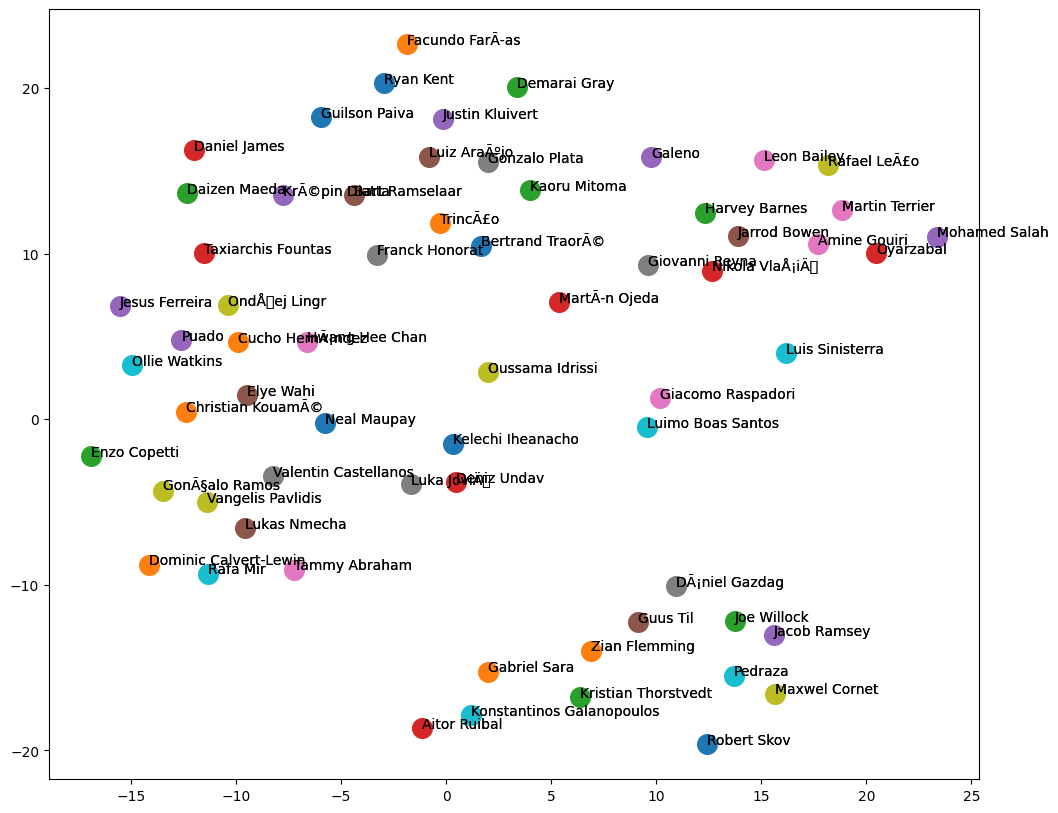

In [229]:
top_players['x'] = coords[:,0]
top_players['y'] = coords[:,1]

plt.figure(figsize=(12,10))
plt.scatter(top_players['x'], top_players['y'])

for _, row in top_players.iterrows():
    if row['player'] == 'Mohamed Salah' or row['player'] in top_players['player'].values:
        plt.scatter(row['x'], row['y'], s=200)
        plt.annotate(row['player'],
                     (row['x'], row['y']))
        plt.text(row['x'], row['y'], row['player'])

In [231]:
kmeans = KMeans(n_clusters= 3, random_state=42)

top_players['cluster'] = kmeans.fit_predict(scaled)

In [235]:
top_players[top_players['cluster'] == 1].sort_values('distance_to_salah')

,player,country,height,weight,age,club,ball_control,dribbling,slide_tackle,stand_tackle,...,attacking_score,midfield_score,defensive_score,position_name,star_player,star_percentile,x,y,distance_to_salah,cluster
63,Mohamed Salah,Egypt,175,71,31,Liverpool,86,88,41,43,...,88.20,84.55,54.85,att,82.2850,99.970484,23.350197,11.037155,0.000000,1
62,Oyarzabal,Spain,181,79,26,Real Sociedad,85,84,30,32,...,82.00,80.55,41.30,att,75.5325,99.262102,20.449799,10.036746,7.876914,1
55,Martin Terrier,France,184,78,26,Stade Rennais FC,82,80,34,31,...,82.45,76.65,44.70,att,75.3375,99.085006,18.862158,12.630982,9.209684,1
35,Amine Gouiri,France,181,83,23,Stade Rennais FC,80,82,32,41,...,80.50,75.75,49.35,att,74.6400,98.819362,17.711468,10.589875,9.723612,1
57,Rafael LeÃ£o,Portugal,188,81,24,Milan,86,89,21,24,...,83.00,76.30,39.40,att,74.7850,98.848878,18.180626,15.355889,9.988363,1
14,Jarrod Bowen,England,175,70,26,West Ham,81,82,36,40,...,78.20,76.30,47.00,att,73.0450,98.110980,13.872076,11.078087,10.854537,1
2,Nikola VlaÅ¡iÄ,Croatia,178,79,25,Torino,80,82,37,52,...,77.40,76.70,49.20,att,72.9950,98.051948,12.635231,8.960546,11.603850,1
25,Giacomo Raspadori,Italy,172,69,23,Napoli FC,83,80,21,23,...,79.60,73.20,35.20,att,71.3400,96.517119,10.164238,1.283078,12.951824,1
26,Valentin Castellanos,Argentina,178,74,24,Girona FC,75,75,39,37,...,78.10,72.95,49.80,att,72.5675,97.727273,-8.217896,-3.437355,13.094180,1
58,Luimo Boas Santos,Brazil,176,73,23,Brazil,81,82,19,20,...,80.55,71.65,35.80,att,71.6125,96.900826,9.569822,-0.473007,13.197211,1


In [245]:
distance_max = top_players['distance_to_salah'].max()
top_players['distance_percentage'] = (1 - top_players['distance_to_salah'] / distance_max ) * 100

In [246]:
top_players

,player,country,height,weight,age,club,ball_control,dribbling,slide_tackle,stand_tackle,...,midfield_score,defensive_score,position_name,star_player,star_percentile,x,y,distance_to_salah,cluster,distance_percentage
0,Dominic Calvert-Lewin,England,187,71,26,Everton,77,73,23,31,...,66.95,48.20,att,70.1675,95.365998,-14.154870,-8.784338,16.932519,1,9.401584
1,Joe Willock,England,179,71,24,Newcastle Utd,78,80,62,75,...,75.90,70.20,att,75.1050,98.996458,13.759944,-12.204380,12.824173,0,31.383528
2,Nikola VlaÅ¡iÄ,Croatia,178,79,25,Torino,80,82,37,52,...,76.70,49.20,att,72.9950,98.051948,12.635231,8.960546,11.603850,1,37.912934
3,Justin Kluivert,Netherlands,172,66,24,Valencia CF,76,81,27,32,...,71.30,39.65,att,69.9725,95.247934,-0.156038,18.152498,15.530007,2,16.905805
4,Luiz AraÃºjo,Brazil,175,70,27,Atlanta United,80,80,41,44,...,73.20,45.70,att,69.8850,95.129870,-0.822631,15.858729,15.646498,2,16.282513
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,Ryan Kent,England,172,65,26,Rangers,75,80,33,44,...,74.70,48.05,att,71.6925,96.989374,-2.931055,20.291323,14.641828,2,21.658059
60,TrincÃ£o,Portugal,184,76,23,Sporting CP,81,83,34,36,...,73.15,44.05,att,69.8950,95.188902,-0.267257,11.831503,14.861488,2,20.482754
61,Harvey Barnes,England,180,66,25,Leicester City,81,80,40,43,...,75.95,48.55,att,73.9400,98.524203,12.339768,12.475871,10.652054,2,43.005575
62,Oyarzabal,Spain,181,79,26,Real Sociedad,85,84,30,32,...,80.55,41.30,att,75.5325,99.262102,20.449799,10.036746,7.876914,1,57.854117
